In [1]:
import pandas as pd
import numpy as np
import utils
import re
import glob
import os
import tidytcells as tt
from typing import Literal
from joblib import Parallel, delayed
import multiprocessing as mp
from collections import defaultdict
import itertools
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
import seaborn as sns
from scipy import stats
import pickle
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

AS = ["COV_144","COV_146","COV_147","COV_154","COV_155"]
moderate = ['COV_156', 'COV_157','COV_48','COV_072','COV_074','COV_76',
    'COV_086','COV_87','COV_089','COV_91','COV_098','COV_101','COV_102']
severe = ['COV_007','COV_009','COV_011','COV_012','COV_013','COV_016',
    'COV_021','COV_029','COV_047','COV_057','COV_077','COV_078']
SR = ['COV_158','COV_159','COV_161','COV_163','COV_037','COV_045',
    'COV_055','COV_119','COV_126','COV_164','COV_165','COV_166']
HC = ['NC_1','NC_05','NC_31','NC_36','NC_07','NC_20','NC_21','NC_23',
    'NC_39','NC_58','NC_60']

/home/yipingzou2/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Analysis

In [2]:
def get_response_category(sample_id):
    """Extract response category from sample ID"""
    if sample_id in HC:
        return "HC"
    elif sample_id in moderate:
        return "moderate"
    elif sample_id in AS:
        return "AS"
    elif sample_id in severe:
        return "severe"
    elif sample_id in SR:
        return "SR"
    else:
        return sample_id
    
def perform_statistical_tests(df_plot, unique_samples, test_direction='two-sided', adjust_pvalues=True, adjust_method="FDR"):
    """
    Perform pairwise statistical comparisons between all samples with one-sided tests
    
    Parameters:
    test_direction: 'greater', 'less', or 'two-sided'
        - 'greater': Test if Sample1 > Sample2 (Sample1 has higher MI values)
        - 'less': Test if Sample1 < Sample2 (Sample1 has lower MI values)
        - 'two-sided': Test if Sample1 ≠ Sample2 (any difference)
    """
    from statsmodels.stats.multitest import multipletests
    
    all_results = []
    
    # Get MI values for each sample
    sample_data = {}
    for sample in unique_samples:
        sample_data[sample] = df_plot[df_plot['Sample_ID'] == sample]['MI_Value'].values
    
    # Perform pairwise comparisons
    total_comparisons = 0
    for sample1, sample2 in combinations(unique_samples, 2):
        total_comparisons += 1
        data1 = sample_data[sample1]
        data2 = sample_data[sample2]
        
        # Also calculate all three for comparison
        _, p_greater = stats.mannwhitneyu(data1, data2, alternative='greater')
        _, p_less = stats.mannwhitneyu(data1, data2, alternative='less')
        _, p_two_sided = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        
        all_results.append({
            'Sample1': sample1,
            'Sample2': sample2,
            'Sample1_Response': get_response_category(sample1),
            'Sample2_Response': get_response_category(sample2),
            'Sample1_Mean': np.mean(data1),
            'Sample2_Mean': np.mean(data2),
            'Mean_Difference': np.mean(data1) - np.mean(data2),
            'P_Value_Raw': p_two_sided if test_direction == 'two-sided' else min(p_less, p_greater),  # This is the p-value for your chosen direction
            'P_Value_less': p_less,
            'P_Value_greater': p_greater,
            'P_Value_Two_Sided': p_two_sided,  # Sample1 ≠ Sample2
            'N1': len(data1),
            'N2': len(data2),
            'Test_Direction': test_direction
        })
    
    # Create DataFrame
    results_df = pd.DataFrame(all_results)
    
    if adjust_pvalues:
        # Apply multiple testing correction to the main p-value
        p_values = results_df['P_Value_Raw'].values 
        
        # Benjamini-Hochberg (FDR) - less conservative than Bonferroni
        rejected_fdr, p_adjusted_fdr, _, _ = multipletests(p_values, method='fdr_bh')
        
        # Bonferroni - more conservative
        rejected_bonf, p_adjusted_bonf, _, _ = multipletests(p_values, method='bonferroni')
        
        results_df['P_Value_FDR'] = p_adjusted_fdr
        results_df['P_Value_Bonferroni'] = p_adjusted_bonf
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        results_df['Significant_FDR'] = rejected_fdr
        results_df['Significant_Bonferroni'] = rejected_bonf
        
        
        # Filter significant results (you can choose which method to use)
        if adjust_method == "FDR":
            found_significant = results_df[results_df['Significant_FDR']].copy()  # Using FDR
        else:
            found_significant = results_df[results_df['Significant_Bonferroni']].copy()
        
    else:
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        found_significant = results_df[results_df['Significant_Raw']].copy()
        
    return results_df, found_significant

In [3]:
def create_pvalue_heatmap(results_df, unique_samples, p_value_type='P_Value_Bonferroni', 
                         save_path=None, feature_pair=None):
    """
    Create upper triangle heatmap of p-values between samples
    
    Parameters:
    - results_df: DataFrame with statistical test results
    - unique_samples: List of sample IDs in desired order
    - p_value_type: Which p-value column to use ('P_Value_Raw', 'P_Value_FDR', 'P_Value_Bonferroni')
    - save_path: Path to save the figure
    - feature_pair: Tuple of (feature1, feature2) for title
    """
    
    # Create p-value matrix
    n_samples = len(unique_samples)
    p_matrix = np.ones((n_samples, n_samples))  # Initialize with 1s (diagonal will be 1)
    
    # Fill the matrix with p-values
    sample_to_idx = {sample: i for i, sample in enumerate(unique_samples)}
    
    for _, row in results_df.iterrows():
        sample1_idx = sample_to_idx[row['Sample1']]
        sample2_idx = sample_to_idx[row['Sample2']]
        p_val = row[p_value_type]
        
        # Fill both positions (symmetric matrix)
        p_matrix[sample1_idx, sample2_idx] = p_val
        p_matrix[sample2_idx, sample1_idx] = p_val
    
    # Create mask for upper triangle (including diagonal)
    mask = np.tril(np.ones_like(p_matrix, dtype=bool))
    
    # Create response category annotations for samples
    sample_responses = [get_response_category(sample) for sample in unique_samples]
    
    # Create color mapping for response categories
    response_colors = {"HC": "#69A3DD", "AS": "#BD2329", 
                      "moderate": "#4048A4", "severe": "#4048A4", "SR": "#4048A4"}
    
    # Create row colors for the heatmap
    row_colors = [response_colors.get(resp, 'gray') for resp in sample_responses]
    
    # Create the plot
    plt.figure(figsize=(6, 5))
    
    # Create heatmap with upper triangle mask
    sns.heatmap(p_matrix, 
                mask=mask,
                annot=True, 
                fmt='.2f',
                cmap='RdYlBu_r',  # Red for low p-values, blue for high p-values
                center=0.05,  # Center colormap at significance threshold
                vmin=0, 
                vmax=1,
                xticklabels=unique_samples,
                yticklabels=unique_samples,
                cbar_kws={'label': f'{p_value_type.replace("_", " ")}'})
    
    # Add response category color bar on the side
    # Create a separate axis for the response category colors
    ax = plt.gca()
    
    # Add colored rectangles for response categories
    for i, (sample, response) in enumerate(zip(unique_samples, sample_responses)):
        color = response_colors.get(response, 'gray')
        # Add color bar on the right side
        rect = plt.Rectangle((len(unique_samples) + 0.1, i), 0.3, 1, 
                           facecolor=color, edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)
    
    # Adjust plot limits to accommodate the color bar
    ax.set_xlim(0, len(unique_samples) + 0.5)
    
    # Create legend for response categories
    legend_elements = []
    unique_responses = list(set(sample_responses))
    for response in ["HC", "AS", "moderate", "severe", "SR"]:  # Maintain order
        if response in unique_responses:
            legend_elements.append(
                plt.Rectangle((0,0),1,1, facecolor=response_colors[response], 
                            edgecolor='black', linewidth=0.5, label=response)
            )
    
    plt.legend(handles=legend_elements, title='Response Category', 
              bbox_to_anchor=(1.15, 1), loc='upper left')
    
    # Set title
    if feature_pair:
        plt.title(f'P-values Heatmap: {feature_pair[0]} vs {feature_pair[1]}\n({p_value_type.replace("_", " ")})')
    else:
        plt.title(f'P-values Heatmap ({p_value_type.replace("_", " ")})')
    
    plt.xlabel('Sample ID')
    plt.ylabel('Sample ID')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path,transparent=True, bbox_inches='tight')
        print(f"Heatmap saved to: {save_path}")
    
    plt.show()

def create_mi_analysis_with_heatmap(mi_path, samples_path, analysis_type='samples', save_dir="figures/covid/samples", 
                                    p_value_type='P_Value_Bonferroni'):
    """
    Create MI analysis with p-value heatmaps for each feature pair.
    
    Parameters:
    - mi_path: Path to MI pickle file
    - samples_path: Path to samples pickle file  
    - analysis_type: 'samples' for individual sample analysis, 'cohorts' for grouped analysis
    - treatment_filter: 'pretreatment', 'posttreatment', or 'both'
    - p_value_type: Which p-value to use in heatmap ('P_Value_Raw', 'P_Value_FDR', 'P_Value_Bonferroni')
    """
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    
    # Create save directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Process each feature pair
    for feature1, feature2 in list(mi.keys()):
        print(f"Processing {feature1} vs {feature2}...")
        
        mi_data = mi[(feature1, feature2)]
        n_resamples = len(mi_data)
        
        # Configuration for samples analysis
        if analysis_type == 'samples':
            sample_ids = list(data_dict.keys())
            response_order = ["HC", "AS", "moderate", "severe", "SR"]
        
            # Prepare plot data
            plot_data = []
            for sample_idx, sample_id in enumerate(sample_ids):
                for resample_idx in range(n_resamples):
                    if resample_idx in mi_data:
                        mi_values_array = mi_data[resample_idx]
                        if sample_idx < len(mi_values_array):
                            plot_data.append({
                                'Sample_ID': sample_id,
                                'Response_Category': get_response_category(sample_id),
                                'MI_Value': mi_values_array[sample_idx],
                                'Resample_Index': resample_idx
                            })
        
        df_plot = pd.DataFrame(plot_data)
        if df_plot.empty:
            print(f"No data found for {feature1} vs {feature2}")
            continue
        
        # Calculate mean MI value for each sample
        sample_means = df_plot.groupby('Sample_ID')['MI_Value'].mean().to_dict()
        
        # Sort samples by response category first, then by mean MI value within category
        def sort_key_by_mean(sample_id):
            response = get_response_category(sample_id)
            response_priority = response_order.index(response) if response in response_order else 999
            mean_mi = sample_means.get(sample_id, 0)
            return (response_priority, -mean_mi)
        
        unique_samples = sorted(df_plot['Sample_ID'].unique(), key=sort_key_by_mean)
        df_plot_limited = df_plot[df_plot['Sample_ID'].isin(unique_samples)]
        
        # Statistical tests
        results_df, found_significant = perform_statistical_tests(
            df_plot_limited, unique_samples, 
            test_direction='one-sided',  # Changed to two-sided for general comparison
            adjust_pvalues=True,
            adjust_method='Bonferroni'
        )
        
        # Create p-value heatmap
        save_path = os.path.join(save_dir, f'pvalue_heatmap_{feature1}_vs_{feature2}.png')
        create_pvalue_heatmap(results_df, unique_samples, 
                            p_value_type=p_value_type,
                            save_path=save_path,
                            feature_pair=(feature1, feature2))
        

In [14]:
def create_combined_mi_plot(mi_path, samples_path, analysis_type='samples', save_dir=None, 
                            p_value_type='P_Value_Bonferroni', select_features=None, 
                            show_individual=False, show_combined=True):
    """
    Create combined plot with boxplot (left) and p-value heatmap (right) for each feature pair.
    Save individual subfigures and create a combined figure with all subfigures.
    """
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    
    # Create save directory if it doesn't exist
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        os.makedirs(os.path.join(save_dir, 'individual_subfigures'), exist_ok=True)
    
    # Store data for all feature pairs for combined plot
    all_plot_data = []
    
    # Process each feature pair
    for feature1, feature2 in list(mi.keys()):
        print(f"Processing {feature1} vs {feature2}...")
        
        mi_data = mi[(feature1, feature2)]
        n_resamples = len(mi_data)
        
        # Configuration for samples analysis
        if analysis_type == 'samples':
            sample_ids = list(data_dict.keys())
            response_order = ["HC", "AS", "moderate", "severe", "SR"]
        
            # Prepare plot data
            plot_data = []
            for sample_idx, sample_id in enumerate(sample_ids):
                for resample_idx in range(n_resamples):
                    if resample_idx in mi_data:
                        mi_values_array = mi_data[resample_idx]
                        if sample_idx < len(mi_values_array):
                            plot_data.append({
                                'Sample_ID': sample_id,
                                'Response_Category': get_response_category(sample_id),
                                'MI_Value': mi_values_array[sample_id],
                                'Resample_Index': resample_idx
                            })
        
        df_plot = pd.DataFrame(plot_data)
        if df_plot.empty:
            print(f"No data found for {feature1} vs {feature2}")
            continue
        
        # Calculate mean MI value for each sample
        sample_means = df_plot.groupby('Sample_ID')['MI_Value'].mean().to_dict()
        
        # Sort samples by response category first, then by mean MI value within category
        def sort_key_by_mean(sample_id):
            response = get_response_category(sample_id)
            response_priority = response_order.index(response) if response in response_order else 999
            mean_mi = sample_means.get(sample_id, 0)
            return (response_priority, -mean_mi)
        
        unique_samples = sorted(df_plot['Sample_ID'].unique(), key=sort_key_by_mean)
        df_plot_limited = df_plot[df_plot['Sample_ID'].isin(unique_samples)]
        
        # Statistical tests
        results_df, found_significant = perform_statistical_tests(
            df_plot_limited, unique_samples, 
            test_direction='one-sided',
            adjust_pvalues=True,
            adjust_method='Bonferroni'
        )
        
        # Store data for combined plot
        all_plot_data.append({
            'feature_pair': (feature1, feature2),
            'df_plot_limited': df_plot_limited,
            'unique_samples': unique_samples,
            'results_df': results_df
        })
        
        # ============ CREATE AND SAVE INDIVIDUAL SUBFIGURE ============
        fig_individual = plt.figure(figsize=(20, 8))
        gs_individual = fig_individual.add_gridspec(1, 3, width_ratios=[2, 2, 0.1], wspace=0.3)
        
        # LEFT PANEL: HORIZONTAL BOXPLOT
        ax1_individual = fig_individual.add_subplot(gs_individual[0, 0])
        response_colors = {"HC": "#69A3DD", "AS": "#BD2329", 
                          "moderate": "#4048A4", "severe": "#4048A4", "SR": "#4048A4"}
        
        sample_palette = {}
        for sample_id in unique_samples:
            response_cat = get_response_category(sample_id)
            sample_palette[sample_id] = response_colors.get(response_cat, 'gray')

        sns.boxplot(y='Sample_ID', x='MI_Value', data=df_plot_limited, 
                order=unique_samples, palette=sample_palette, 
                showfliers=True, width=0.6, ax=ax1_individual, orient='h')

        ax1_individual.xaxis.tick_top()
        ax1_individual.xaxis.set_label_position('top')
        ax1_individual.set_yticklabels(unique_samples, rotation=0)
        ax1_individual.set_title(f'MI Distribution: {feature1} vs {feature2}')
        ax1_individual.set_ylabel('Sample ID')
        ax1_individual.set_xlabel('Mutual Information Value')
        
        # RIGHT PANEL: HEATMAP
        ax2_individual = fig_individual.add_subplot(gs_individual[0, 1])
        n_samples = len(unique_samples)
        p_matrix = np.ones((n_samples, n_samples))
        sample_to_idx = {sample: i for i, sample in enumerate(unique_samples)}

        for _, row in results_df.iterrows():
            sample1_idx = sample_to_idx[row['Sample1']]
            sample2_idx = sample_to_idx[row['Sample2']]
            p_val = row[p_value_type]
            p_matrix[sample1_idx, sample2_idx] = p_val
            p_matrix[sample2_idx, sample1_idx] = p_val

        mask = np.zeros_like(p_matrix, dtype=bool)
        for i in range(n_samples):
            for j in range(n_samples):
                if j >= i:
                    mask[i, j] = True

        im_individual = sns.heatmap(p_matrix, 
                        mask=mask,
                        annot=True, 
                        fmt='.2f',
                        cmap='Blues_r',
                        vmin=0, 
                        vmax=1,
                        xticklabels=unique_samples,
                        yticklabels=unique_samples,
                        ax=ax2_individual,
                        cbar=False)

        ax2_individual.set_title(f'P-values ({p_value_type.replace("_", " ")})')
        ax2_individual.set_xlabel('Sample ID')
        ax2_individual.set_ylabel('Sample ID')
        ax2_individual.set_xticklabels(unique_samples, rotation=45, ha='right')
        ax2_individual.set_yticklabels(unique_samples, rotation=0)
        
        # COLORBAR
        ax3_individual = fig_individual.add_subplot(gs_individual[0, 2])
        cbar_individual = plt.colorbar(im_individual.collections[0], cax=ax3_individual)
        cbar_individual.set_label(f'{p_value_type.replace("_", " ")}', rotation=270, labelpad=20)
        
        # LEGEND
        legend_elements = []
        sample_responses = [get_response_category(sample) for sample in unique_samples]
        unique_responses = list(set(sample_responses))
        
        for response in ["HC", "AS", "moderate", "severe", "SR"]:
            if response in unique_responses:
                legend_elements.append(
                    plt.Rectangle((0,0),1,1, facecolor=response_colors[response], 
                                edgecolor='black', linewidth=0.5, label=response)
                )
        
        fig_individual.legend(handles=legend_elements, title='Response Category', 
                  bbox_to_anchor=(0.95, 0.85), loc='upper left')
        
        plt.suptitle(f'MI Analysis: {feature1} vs {feature2}', fontsize=16, y=0.95)
        
        # Save individual subfigure
        if save_dir:
            if select_features is None or (feature1, feature2) in select_features:
                individual_save_path = os.path.join(save_dir, 'individual_subfigures', 
                                                  f'subfigure_{feature1}_vs_{feature2}.pdf')
                fig_individual.savefig(individual_save_path, transparent=True, bbox_inches='tight')
                print(f"Individual subfigure saved to: {individual_save_path}")
        
        # Show individual plot if requested
        if show_individual:
            plt.show()
        else:
            plt.close(fig_individual)  # Close to prevent display in notebook
    
    # ============ CREATE COMBINED FIGURE WITH ALL SUBFIGURES ============
    if not all_plot_data:
        print("No data to create combined figure")
        return
    
    n_pairs = len(all_plot_data)
    n_cols = min(2, n_pairs)  # 最多2列
    n_rows = (n_pairs + n_cols - 1) // n_cols
    
    # Create combined figure
    fig_combined = plt.figure(figsize=(20*n_cols, 8*n_rows))
    
    for idx, data in enumerate(all_plot_data):
        feature1, feature2 = data['feature_pair']
        df_plot_limited = data['df_plot_limited']
        unique_samples = data['unique_samples']
        results_df = data['results_df']
        
        # Calculate subplot position
        row = idx // n_cols
        col = idx % n_cols
        
        # Create gridspec for this subplot
        gs_sub = fig_combined.add_gridspec(n_rows, n_cols*3, 
                                          width_ratios=[2, 2, 0.1]*n_cols, 
                                          wspace=0.1, hspace=0.3)
        
        # LEFT PANEL: BOXPLOT
        ax1 = fig_combined.add_subplot(gs_sub[row, col*3])
        
        response_colors = {"HC": "#69A3DD", "AS": "#BD2329", 
                          "moderate": "#4048A4", "severe": "#4048A4", "SR": "#4048A4"}
        
        sample_palette = {}
        for sample_id in unique_samples:
            response_cat = get_response_category(sample_id)
            sample_palette[sample_id] = response_colors.get(response_cat, 'gray')

        sns.boxplot(y='Sample_ID', x='MI_Value', data=df_plot_limited, 
                order=unique_samples, palette=sample_palette, 
                showfliers=False, width=0.6, ax=ax1, orient='h')

        ax1.xaxis.tick_top()
        ax1.xaxis.set_label_position('top')
        ax1.set_yticklabels(unique_samples, rotation=0, fontsize=8)
        ax1.set_title(f'MI: {feature1} vs {feature2}', fontsize=10)
        ax1.set_ylabel('Sample ID', fontsize=9)
        ax1.set_xlabel('MI Value', fontsize=9)
        
        # RIGHT PANEL: HEATMAP
        ax2 = fig_combined.add_subplot(gs_sub[row, col*3+1])
        
        n_samples = len(unique_samples)
        p_matrix = np.ones((n_samples, n_samples))
        sample_to_idx = {sample: i for i, sample in enumerate(unique_samples)}

        for _, row_data in results_df.iterrows():
            sample1_idx = sample_to_idx[row_data['Sample1']]
            sample2_idx = sample_to_idx[row_data['Sample2']]
            p_val = row_data[p_value_type]
            p_matrix[sample1_idx, sample2_idx] = p_val
            p_matrix[sample2_idx, sample1_idx] = p_val

        mask = np.zeros_like(p_matrix, dtype=bool)
        for i in range(n_samples):
            for j in range(n_samples):
                if j >= i:
                    mask[i, j] = True

        im = sns.heatmap(p_matrix, 
                        mask=mask,
                        annot=True, 
                        fmt='.2f',
                        cmap='Blues_r',
                        vmin=0, 
                        vmax=1,
                        xticklabels=unique_samples,
                        yticklabels=unique_samples,
                        ax=ax2,
                        cbar=False)

        ax2.set_title(f'P-values', fontsize=10)
        ax2.set_xlabel('Sample ID', fontsize=9)
        ax2.set_ylabel('Sample ID', fontsize=9)
        ax2.set_xticklabels(unique_samples, rotation=45, ha='right', fontsize=8)
        ax2.set_yticklabels(unique_samples, rotation=0, fontsize=8)
        
        # COLORBAR
        ax3 = fig_combined.add_subplot(gs_sub[row, col*3+2])
        cbar = plt.colorbar(im.collections[0], cax=ax3)
        cbar.set_label(f'{p_value_type.replace("_", " ")}', rotation=270, labelpad=15, fontsize=8)
        cbar.ax.tick_params(labelsize=8)
    
    # Add overall legend
    legend_elements = []
    response_colors = {"HC": "#69A3DD", "AS": "#BD2329", 
                      "moderate": "#4048A4", "severe": "#4048A4", "SR": "#4048A4"}
    
    for response in ["HC", "AS", "moderate", "severe", "SR"]:
        legend_elements.append(
            plt.Rectangle((0,0),1,1, facecolor=response_colors[response], 
                        edgecolor='black', linewidth=0.5, label=response)
        )
    
    fig_combined.legend(handles=legend_elements, title='Response Category', 
              bbox_to_anchor=(0.98, 0.98), loc='upper right', fontsize=10)
    
    plt.suptitle('Combined MI Analysis - All Feature Pairs', fontsize=16, y=0.98)
    
    # Save combined figure
    if save_dir:
        combined_save_path = os.path.join(save_dir, 'combined_all_analyses_300.pdf')
        fig_combined.savefig(combined_save_path, transparent=True, bbox_inches='tight')
        print(f"Combined figure saved to: {combined_save_path}")
    
    # Show combined plot if requested
    if show_combined:
        plt.show()
    else:
        plt.close(fig_combined)


Processing TRAV vs TRBV...
Individual subfigure saved to: /mnt/d/TCRMI/figures/covid/cohort/individual_subfigures/subfigure_TRAV_vs_TRBV.pdf
Processing TRAV vs cdr3B...
Individual subfigure saved to: /mnt/d/TCRMI/figures/covid/cohort/individual_subfigures/subfigure_TRAV_vs_cdr3B.pdf
Processing TRAJ vs TRBJ...
Individual subfigure saved to: /mnt/d/TCRMI/figures/covid/cohort/individual_subfigures/subfigure_TRAJ_vs_TRBJ.pdf
Processing TRAJ vs cdr3B...
Individual subfigure saved to: /mnt/d/TCRMI/figures/covid/cohort/individual_subfigures/subfigure_TRAJ_vs_cdr3B.pdf
Processing cdr3A vs TRBV...
Individual subfigure saved to: /mnt/d/TCRMI/figures/covid/cohort/individual_subfigures/subfigure_cdr3A_vs_TRBV.pdf
Processing cdr3A vs cdr3B...
Individual subfigure saved to: /mnt/d/TCRMI/figures/covid/cohort/individual_subfigures/subfigure_cdr3A_vs_cdr3B.pdf
Processing cdr3A vs TRBJ...
Individual subfigure saved to: /mnt/d/TCRMI/figures/covid/cohort/individual_subfigures/subfigure_cdr3A_vs_TRBJ.pdf
P

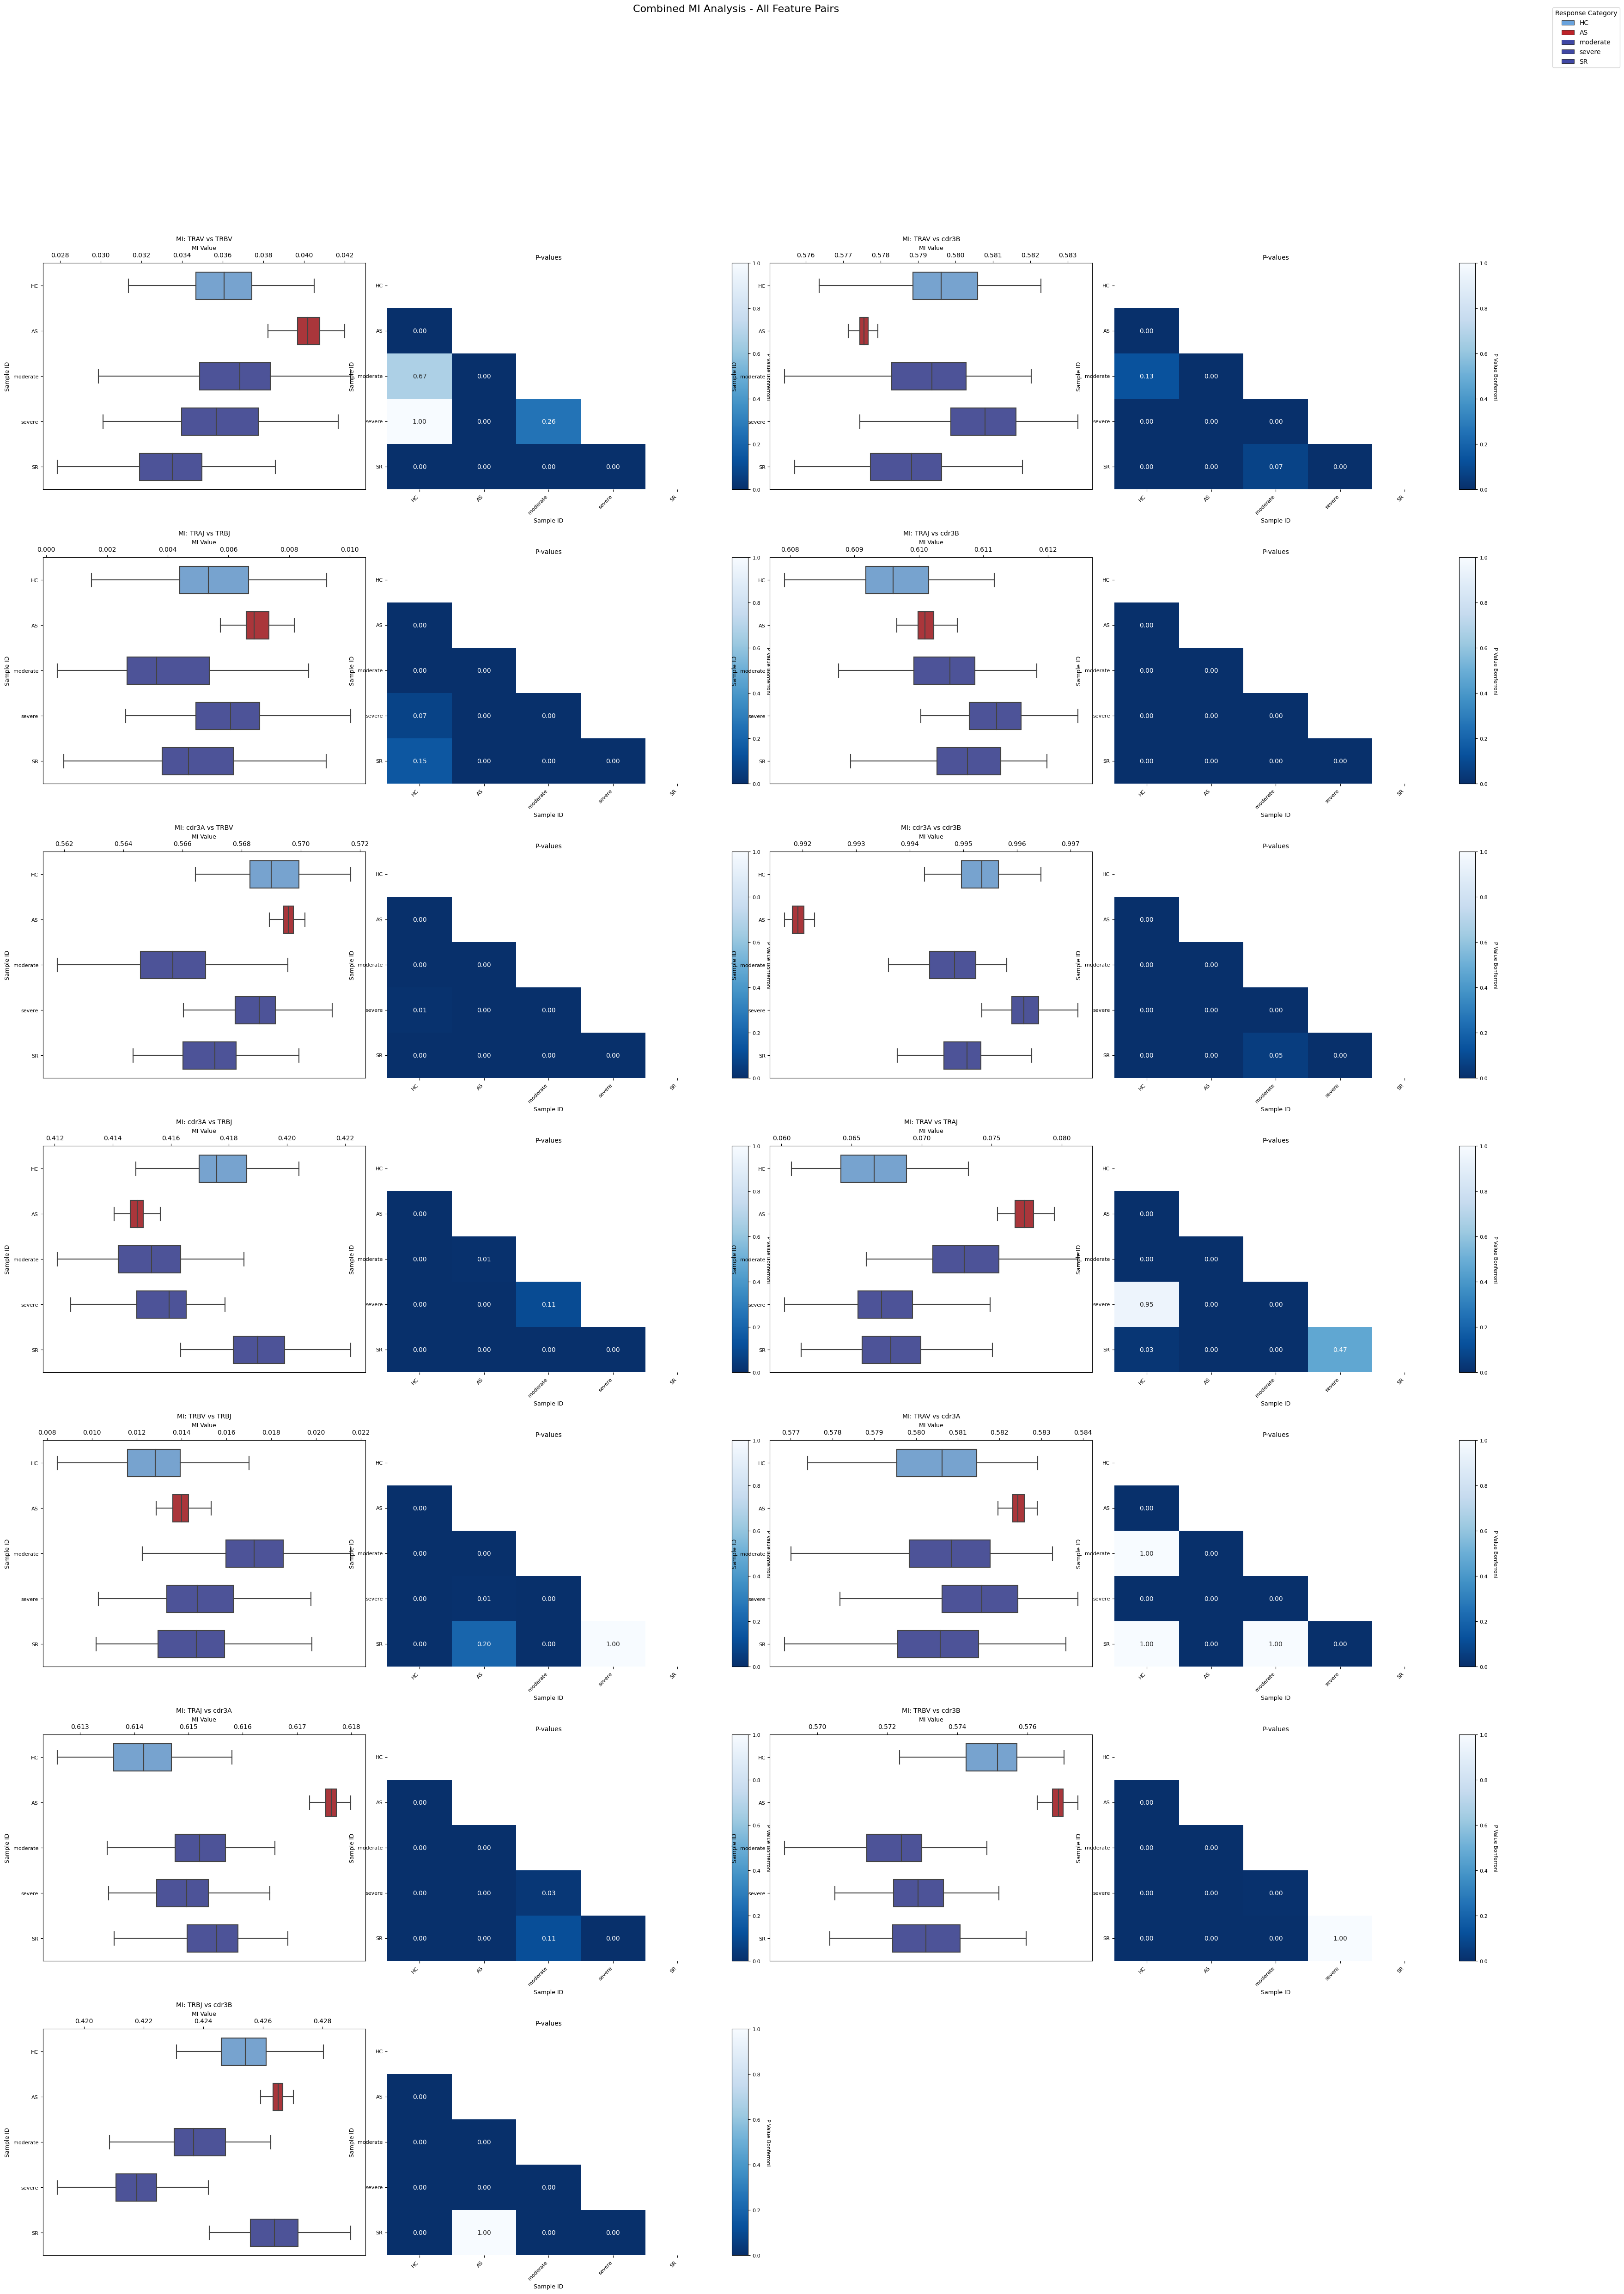

In [7]:
create_combined_mi_plot("/mnt/d/TCRMI/results/covid/cohort/mi.pickle", 
                  "/mnt/d/TCRMI/results/covid/cohort.pickle",
                  save_dir='/mnt/d/TCRMI/figures/covid/cohort',
                  select_features=[('TRAV', 'TRBV'), ('cdr3A', 'cdr3B'),
                                    ('TRAV', 'cdr3B'), ('cdr3A', 'TRBV'),
                                    ('TRAJ', 'TRBJ'), ('cdr3A', 'TRBJ'),
                                    ('TRAJ', 'cdr3B'),])

In [8]:
def create_clean_prepost_dumbbell_plot(results_df, p_value_column='P_Value_FDR', 
                                      significance_threshold=0.05, figsize=(10, 6)):
    """
    Create a clean dumbbell plot showing only significant pre-post connections
    """
    if results_df.empty:
        return None, None
    
    cohorts = ['CR', 'PR', 'NR', 'Relapsed']
    cohort_colors = {'CR': '#B3242A', 'PR': '#4169E1', 'NR': '#F3627B', 'Relapsed': '#9496C4'}
    
    # Extract pre-post data
    plot_data = []
    for cohort in cohorts:
        # Find the pre-post comparison for this cohort
        cohort_data = None
        for _, row in results_df.iterrows():
            sample1, sample2 = row['Sample1'], row['Sample2']
            
            if ((sample1 == f'{cohort}_pre' and sample2 == f'{cohort}_post') or 
                (sample1 == f'{cohort}_post' and sample2 == f'{cohort}_pre')):
                
                p_val = row[p_value_column]
                mean_diff = row['Mean_Difference'] if sample1.endswith('_pre') else -row['Mean_Difference']
                
                cohort_data = {
                    'cohort': cohort,
                    'pre_value': 0,  # Baseline at 0
                    'post_value': mean_diff,  # Change from baseline
                    'significant': p_val < significance_threshold,
                    'p_value': p_val,
                    'mean_diff': mean_diff
                }
                break
        
        # Add data even if not found (will show as non-significant)
        if cohort_data is None:
            cohort_data = {
                'cohort': cohort,
                'pre_value': 0,
                'post_value': 0,
                'significant': False,
                'p_value': 1.0,
                'mean_diff': 0
            }
        
        plot_data.append(cohort_data)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Set y positions for each cohort
    y_positions = np.arange(len(cohorts))
    
    for i, data in enumerate(plot_data):
        cohort = data['cohort']
        color = cohort_colors[cohort]
        pre_val = data['pre_value']
        post_val = data['post_value']
        y_pos = i
        
        # Always show the pre and post points
        ax.scatter(pre_val, y_pos, s=120, c='white', edgecolors=color, 
                  linewidth=2, zorder=3, label='Pre' if i == 0 else "")
        ax.scatter(post_val, y_pos, s=120, c=color, edgecolors=color, 
                  linewidth=2, zorder=3, label='Post' if i == 0 else "")
        
        # Only draw connecting line if significant
        if data['significant']:
            # Line thickness based on significance level
            if data['p_value'] < 0.001:
                linewidth = 4
                alpha = 1.0
                stars = '***'
            elif data['p_value'] < 0.01:
                linewidth = 3
                alpha = 0.9
                stars = '**'
            else:
                linewidth = 2
                alpha = 0.8
                stars = '*'
            
            # Draw connecting line
            ax.plot([pre_val, post_val], [y_pos, y_pos], color=color, 
                   linewidth=linewidth, alpha=alpha, solid_capstyle='round', zorder=2)
            
            # Add significance stars only
            star_x = max(pre_val, post_val) + (max(abs(pre_val), abs(post_val)) * 0.1)
            ax.text(star_x, y_pos, f'{stars}', ha='left', va='center', 
                   fontsize=12, fontweight='bold', color='red')
        
        else:
            # For non-significant, just show a faint line
            ax.plot([pre_val, post_val], [y_pos, y_pos], color='lightgray', 
                   linewidth=1, alpha=0.3, linestyle='--', zorder=1)
    
    # Customize plot
    ax.set_yticks(y_positions)
    ax.set_yticklabels(cohorts, fontsize=12, fontweight='bold')
    ax.set_xlabel('Treatment Effect (Change from Baseline)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Response Groups', fontsize=12, fontweight='bold')
    
    # Add reference line at x=0
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    
    # Set x-axis limits with some padding
    all_values = [d['pre_value'] for d in plot_data] + [d['post_value'] for d in plot_data]
    x_min, x_max = min(all_values), max(all_values)
    x_range = x_max - x_min
    ax.set_xlim(x_min - x_range*0.1, x_max + x_range*0.3)  # Reduced padding since no p-values
    
    # Title
    significant_count = sum(1 for d in plot_data if d['significant'])
    ax.set_title(f'Pre-Post Treatment Response Changes\n{significant_count}/{len(cohorts)} cohorts show significant changes', 
                fontsize=14, fontweight='bold', pad=20)
    
    # Legend
    legend_elements = [
        plt.scatter([], [], s=80, c='white', edgecolors='black', linewidth=2, label='Pre-treatment'),
        plt.scatter([], [], s=80, c='black', edgecolors='black', linewidth=2, label='Post-treatment'),
        plt.Line2D([0], [0], color='black', lw=4, label='p < 0.001 ***'),
        plt.Line2D([0], [0], color='black', lw=3, label='p < 0.01 **'),
        plt.Line2D([0], [0], color='black', lw=2, label='p < 0.05 *'),
        plt.Line2D([0], [0], color='lightgray', lw=1, linestyle='--', alpha=0.3, label='Non-significant')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='x')
    
    # Invert y-axis so first cohort is at top
    ax.invert_yaxis()
    
    plt.tight_layout()
    return fig, ax


# Entropy

In [10]:
def create_combined_entropy_plot(mi_path, samples_path, analysis_type='samples', save_dir=None, 
                            p_value_type='P_Value_Bonferroni', select_features=None):
    """
    Create combined plot with boxplot (left) and p-value heatmap (right) for each feature pair.
    """
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    
    # Create save directory if it doesn't exist
    #os.makedirs(save_dir, exist_ok=True)
    
    # Process each feature pair
    for feature in list(mi.keys()):
        print(f"Processing {feature}...")
        
        mi_data = mi[(feature)]
        n_resamples = len(mi_data)
        
        # Configuration for samples analysis
        if analysis_type == 'samples':
            sample_ids = list(data_dict.keys())
            response_order = ["HC", "AS", "moderate", "severe", "SR"]
        
            # Prepare plot data
            plot_data = []
            for sample_idx, sample_id in enumerate(sample_ids):
                for resample_idx in range(n_resamples):
                    if resample_idx in mi_data:
                        mi_values_array = mi_data[resample_idx]
                        if sample_idx < len(mi_values_array):
                            plot_data.append({
                                'Sample_ID': sample_id,
                                'Response_Category': get_response_category(sample_id),
                                'MI_Value': mi_values_array[sample_id],
                                'Resample_Index': resample_idx
                            })
        
        df_plot = pd.DataFrame(plot_data)
        if df_plot.empty:
            print(f"No data found for {feature}")
            continue
        
        # Calculate mean MI value for each sample
        sample_means = df_plot.groupby('Sample_ID')['MI_Value'].mean().to_dict()
        
        # Sort samples by response category first, then by mean MI value within category
        def sort_key_by_mean(sample_id):
            response = get_response_category(sample_id)
            response_priority = response_order.index(response) if response in response_order else 999
            mean_mi = sample_means.get(sample_id, 0)
            return (response_priority, -mean_mi)
        
        unique_samples = sorted(df_plot['Sample_ID'].unique(), key=sort_key_by_mean)
        df_plot_limited = df_plot[df_plot['Sample_ID'].isin(unique_samples)]
        
        # Statistical tests
        results_df, found_significant = perform_statistical_tests(
            df_plot_limited, unique_samples, 
            test_direction='one-sided',
            adjust_pvalues=True,
            adjust_method='Bonferroni'
        )
        
        # Create the combined plot
        fig = plt.figure(figsize=(20, 8))
        
        # Create gridspec for custom layout
        gs = fig.add_gridspec(1, 3, width_ratios=[2, 2, 0.1], wspace=0.3)
        
        # ============ LEFT PANEL: HORIZONTAL BOXPLOT ============
        ax1 = fig.add_subplot(gs[0, 0])

        # Create color mapping for response categories
        response_colors = {"HC": "#69A3DD", "AS": "#BD2329", 
                        "moderate": "#4048A4", "severe": "#4048A4", "SR": "#4048A4"}

        # Create palette for samples based on their response category
        sample_palette = {}
        for sample_id in unique_samples:
            response_cat = get_response_category(sample_id)
            sample_palette[sample_id] = response_colors.get(response_cat, 'gray')

        # Create HORIZONTAL boxplot (y=Sample_ID, x=MI_Value)
        sns.boxplot(y='Sample_ID', x='MI_Value', data=df_plot_limited, 
                order=unique_samples, palette=sample_palette, 
                showfliers=True, width=0.6, ax=ax1, orient='h')

        # Move x-axis (MI values) to the right side
        ax1.xaxis.tick_top()
        ax1.xaxis.set_label_position('top')

        # Set labels and title
        ax1.set_yticklabels(unique_samples, rotation=0)
        ax1.set_title(f'Entropy Distribution: {feature}')
        ax1.set_ylabel('Sample ID')
        ax1.set_xlabel('Entropy Value')
        
        # ============ RIGHT PANEL: HEATMAP ============
        ax2 = fig.add_subplot(gs[0, 1])

        # Create p-value matrix
        n_samples = len(unique_samples)
        p_matrix = np.ones((n_samples, n_samples))

        # Fill the matrix with p-values
        sample_to_idx = {sample: i for i, sample in enumerate(unique_samples)}

        for _, row in results_df.iterrows():
            sample1_idx = sample_to_idx[row['Sample1']]
            sample2_idx = sample_to_idx[row['Sample2']]
            p_val = row[p_value_type]
            
            # Fill both positions (symmetric matrix)
            p_matrix[sample1_idx, sample2_idx] = p_val
            p_matrix[sample2_idx, sample1_idx] = p_val

        # Create mask for lower-right triangle - this will HIDE the lower-right triangle
        # To show UPPER-LEFT triangle, we need to mask where j > i (upper-right) and i >= j (diagonal + lower-left)
        mask = np.zeros_like(p_matrix, dtype=bool)
        for i in range(n_samples):
            for j in range(n_samples):
                if j >= i:  # This masks the diagonal and upper-right triangle
                    mask[i, j] = True

        # Create heatmap
        im = sns.heatmap(p_matrix, 
                        mask=mask,
                        annot=True, 
                        fmt='.2f',
                        cmap='Blues_r',  # Reversed Blues: darker for smaller values (closer to 0)
                        vmin=0, 
                        vmax=1,
                        xticklabels=unique_samples,
                        yticklabels=unique_samples,
                        ax=ax2,
                        cbar=False)

        ax2.set_title(f'P-values ({p_value_type.replace("_", " ")})')
        ax2.set_xlabel('Sample ID')
        ax2.set_ylabel('Sample ID')
        ax2.set_xticklabels(unique_samples, rotation=45, ha='right')
        ax2.set_yticklabels(unique_samples, rotation=0)
        
        # ============ COLORBAR ============
        ax3 = fig.add_subplot(gs[0, 2])
        
        # Create colorbar for heatmap
        cbar = plt.colorbar(im.collections[0], cax=ax3)
        cbar.set_label(f'{p_value_type.replace("_", " ")}', rotation=270, labelpad=20)
        
        # ============ RESPONSE CATEGORY LEGEND ============
        # Create legend for response categories
        legend_elements = []
        sample_responses = [get_response_category(sample) for sample in unique_samples]
        unique_responses = list(set(sample_responses))
        
        for response in ["HC", "AS", "moderate", "severe", "SR"]:
            if response in unique_responses:
                legend_elements.append(
                    plt.Rectangle((0,0),1,1, facecolor=response_colors[response], 
                                edgecolor='black', linewidth=0.5, label=response)
                )
        
        # Add legend to the figure
        fig.legend(handles=legend_elements, title='Response Category', 
                  bbox_to_anchor=(0.95, 0.85), loc='upper left')
        
        # ============ SAVE AND SHOW ============
        plt.suptitle(f'Entropy Analysis: {feature}', fontsize=16, y=0.95)
        
        if save_dir:
            if feature in select_features:
                save_path = os.path.join(save_dir, f'Entropy_plot_{feature}.pdf')
                plt.savefig(save_path, transparent=True, bbox_inches='tight')
                print(f"Combined plot saved to: {save_path}")

In [20]:
def create_combined_entropy_plot(mi_path, samples_path, analysis_type='samples', save_dir=None, 
                            p_value_type='P_Value_Bonferroni', select_features=None,
                            show_individual=False, show_combined=True):
    """
    Create combined plot with boxplot (left) and p-value heatmap (right) for each feature.
    Save individual subfigures and create a combined figure with all subfigures.
    """
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    
    # Create save directory if it doesn't exist
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        os.makedirs(os.path.join(save_dir, 'individual_subfigures'), exist_ok=True)
    
    # Store data for all features for combined plot
    all_plot_data = []
    
    # Process each feature
    for feature in list(mi.keys()):
        print(f"Processing {feature}...")
        
        mi_data = mi[feature]
        n_resamples = len(mi_data)
        
        # Configuration for samples analysis
        if analysis_type == 'samples':
            sample_ids = list(data_dict.keys())
            response_order = ["HC", "AS", "moderate", "severe", "SR"]
        
            # Prepare plot data
            plot_data = []
            for sample_idx, sample_id in enumerate(sample_ids):
                for resample_idx in range(n_resamples):
                    if resample_idx in mi_data:
                        mi_values_array = mi_data[resample_idx]
                        if sample_idx < len(mi_values_array):
                            plot_data.append({
                                'Sample_ID': sample_id,
                                'Response_Category': get_response_category(sample_id),
                                'MI_Value': mi_values_array[sample_id],
                                'Resample_Index': resample_idx
                            })
        
        df_plot = pd.DataFrame(plot_data)
        if df_plot.empty:
            print(f"No data found for {feature}")
            continue
        
        # Calculate mean entropy value for each sample
        sample_means = df_plot.groupby('Sample_ID')['MI_Value'].mean().to_dict()
        
        # Sort samples by response category first, then by mean entropy value within category
        def sort_key_by_mean(sample_id):
            response = get_response_category(sample_id)
            response_priority = response_order.index(response) if response in response_order else 999
            mean_mi = sample_means.get(sample_id, 0)
            return (response_priority, -mean_mi)
        
        unique_samples = sorted(df_plot['Sample_ID'].unique(), key=sort_key_by_mean)
        df_plot_limited = df_plot[df_plot['Sample_ID'].isin(unique_samples)]
        
        # Statistical tests
        results_df, found_significant = perform_statistical_tests(
            df_plot_limited, unique_samples, 
            test_direction='one-sided',
            adjust_pvalues=True,
            adjust_method='Bonferroni'
        )
        
        # Store data for combined plot
        all_plot_data.append({
            'feature': feature,
            'df_plot_limited': df_plot_limited,
            'unique_samples': unique_samples,
            'results_df': results_df
        })
        
        # ============ CREATE AND SAVE INDIVIDUAL SUBFIGURE ============
        fig_individual = plt.figure(figsize=(20, 8))
        gs_individual = fig_individual.add_gridspec(1, 3, width_ratios=[2, 2, 0.1], wspace=0.3)
        
        # LEFT PANEL: HORIZONTAL BOXPLOT
        ax1_individual = fig_individual.add_subplot(gs_individual[0, 0])
        response_colors = {"HC": "#69A3DD", "AS": "#BD2329", 
                          "moderate": "#4048A4", "severe": "#4048A4", "SR": "#4048A4"}
        
        sample_palette = {}
        for sample_id in unique_samples:
            response_cat = get_response_category(sample_id)
            sample_palette[sample_id] = response_colors.get(response_cat, 'gray')

        sns.boxplot(y='Sample_ID', x='MI_Value', data=df_plot_limited, 
                order=unique_samples, palette=sample_palette, 
                showfliers=False, width=0.6, ax=ax1_individual, orient='h')

        ax1_individual.xaxis.tick_top()
        ax1_individual.xaxis.set_label_position('top')
        ax1_individual.set_yticklabels(unique_samples, rotation=0)
        ax1_individual.set_title(f'Entropy Distribution: {feature}')
        ax1_individual.set_ylabel('Sample ID')
        ax1_individual.set_xlabel('Entropy Value')
        
        # RIGHT PANEL: HEATMAP
        ax2_individual = fig_individual.add_subplot(gs_individual[0, 1])
        n_samples = len(unique_samples)
        p_matrix = np.ones((n_samples, n_samples))
        sample_to_idx = {sample: i for i, sample in enumerate(unique_samples)}

        for _, row in results_df.iterrows():
            sample1_idx = sample_to_idx[row['Sample1']]
            sample2_idx = sample_to_idx[row['Sample2']]
            p_val = row[p_value_type]
            p_matrix[sample1_idx, sample2_idx] = p_val
            p_matrix[sample2_idx, sample1_idx] = p_val

        mask = np.zeros_like(p_matrix, dtype=bool)
        for i in range(n_samples):
            for j in range(n_samples):
                if j >= i:
                    mask[i, j] = True

        im_individual = sns.heatmap(p_matrix, 
                        mask=mask,
                        annot=True, 
                        fmt='.2f',
                        cmap='Blues_r',
                        vmin=0, 
                        vmax=1,
                        xticklabels=unique_samples,
                        yticklabels=unique_samples,
                        ax=ax2_individual,
                        cbar=False)

        ax2_individual.set_title(f'P-values ({p_value_type.replace("_", " ")})')
        ax2_individual.set_xlabel('Sample ID')
        ax2_individual.set_ylabel('Sample ID')
        ax2_individual.set_xticklabels(unique_samples, rotation=45, ha='right')
        ax2_individual.set_yticklabels(unique_samples, rotation=0)
        
        # COLORBAR
        ax3_individual = fig_individual.add_subplot(gs_individual[0, 2])
        cbar_individual = plt.colorbar(im_individual.collections[0], cax=ax3_individual)
        cbar_individual.set_label(f'{p_value_type.replace("_", " ")}', rotation=270, labelpad=20)
        
        # LEGEND
        legend_elements = []
        sample_responses = [get_response_category(sample) for sample in unique_samples]
        unique_responses = list(set(sample_responses))
        
        for response in ["HC", "AS", "moderate", "severe", "SR"]:
            if response in unique_responses:
                legend_elements.append(
                    plt.Rectangle((0,0),1,1, facecolor=response_colors[response], 
                                edgecolor='black', linewidth=0.5, label=response)
                )
        
        fig_individual.legend(handles=legend_elements, title='Response Category', 
                  bbox_to_anchor=(0.95, 0.85), loc='upper left')
        
        plt.suptitle(f'Entropy Analysis: {feature}', fontsize=16, y=0.95)
        
        # Save individual subfigure
        if save_dir:
            if select_features is None or feature in select_features:
                individual_save_path = os.path.join(save_dir, 'individual_subfigures', 
                                                  f'entropy_subfigure_{feature}.pdf')
                fig_individual.savefig(individual_save_path, transparent=True, bbox_inches='tight')
                print(f"Individual entropy subfigure saved to: {individual_save_path}")
        
        # Show individual plot if requested
        if show_individual:
            plt.show()
        else:
            plt.close(fig_individual)  # Close to prevent display in notebook
    
    # ============ CREATE COMBINED FIGURE WITH ALL SUBFIGURES ============
    if not all_plot_data:
        print("No data to create combined figure")
        return
    
    n_features = len(all_plot_data)
    n_cols = min(2, n_features)  # 最多2列
    n_rows = (n_features + n_cols - 1) // n_cols
    
    # Create combined figure
    fig_combined = plt.figure(figsize=(20*n_cols, 8*n_rows))
    
    for idx, data in enumerate(all_plot_data):
        feature = data['feature']
        df_plot_limited = data['df_plot_limited']
        unique_samples = data['unique_samples']
        results_df = data['results_df']
        
        # Calculate subplot position
        row = idx // n_cols
        col = idx % n_cols
        
        # Create gridspec for this subplot
        gs_sub = fig_combined.add_gridspec(n_rows, n_cols*3, 
                                          width_ratios=[2, 2, 0.1]*n_cols, 
                                          wspace=0.1, hspace=0.3)
        
        # LEFT PANEL: BOXPLOT
        ax1 = fig_combined.add_subplot(gs_sub[row, col*3])
        
        response_colors = {"HC": "#69A3DD", "AS": "#BD2329", 
                          "moderate": "#4048A4", "severe": "#4048A4", "SR": "#4048A4"}
        
        sample_palette = {}
        for sample_id in unique_samples:
            response_cat = get_response_category(sample_id)
            sample_palette[sample_id] = response_colors.get(response_cat, 'gray')

        sns.boxplot(y='Sample_ID', x='MI_Value', data=df_plot_limited, 
                order=unique_samples, palette=sample_palette, 
                showfliers=False, width=0.6, ax=ax1, orient='h')

        ax1.xaxis.tick_top()
        ax1.xaxis.set_label_position('top')
        ax1.set_yticklabels(unique_samples, rotation=0, fontsize=8)
        ax1.set_title(f'Entropy: {feature}', fontsize=10)
        ax1.set_ylabel('Sample ID', fontsize=9)
        ax1.set_xlabel('Entropy Value', fontsize=9)
        
        # RIGHT PANEL: HEATMAP
        ax2 = fig_combined.add_subplot(gs_sub[row, col*3+1])
        
        n_samples = len(unique_samples)
        p_matrix = np.ones((n_samples, n_samples))
        sample_to_idx = {sample: i for i, sample in enumerate(unique_samples)}

        for _, row_data in results_df.iterrows():
            sample1_idx = sample_to_idx[row_data['Sample1']]
            sample2_idx = sample_to_idx[row_data['Sample2']]
            p_val = row_data[p_value_type]
            p_matrix[sample1_idx, sample2_idx] = p_val
            p_matrix[sample2_idx, sample1_idx] = p_val

        mask = np.zeros_like(p_matrix, dtype=bool)
        for i in range(n_samples):
            for j in range(n_samples):
                if j >= i:
                    mask[i, j] = True

        im = sns.heatmap(p_matrix, 
                        mask=mask,
                        annot=True, 
                        fmt='.2f',
                        cmap='Blues_r',
                        vmin=0, 
                        vmax=1,
                        xticklabels=unique_samples,
                        yticklabels=unique_samples,
                        ax=ax2,
                        cbar=False)

        ax2.set_title(f'P-values', fontsize=10)
        ax2.set_xlabel('Sample ID', fontsize=9)
        ax2.set_ylabel('Sample ID', fontsize=9)
        ax2.set_xticklabels(unique_samples, rotation=45, ha='right', fontsize=8)
        ax2.set_yticklabels(unique_samples, rotation=0, fontsize=8)
        
        # COLORBAR
        ax3 = fig_combined.add_subplot(gs_sub[row, col*3+2])
        cbar = plt.colorbar(im.collections[0], cax=ax3)
        cbar.set_label(f'{p_value_type.replace("_", " ")}', rotation=270, labelpad=15, fontsize=8)
        cbar.ax.tick_params(labelsize=8)
    
    # Add overall legend
    legend_elements = []
    response_colors = {"HC": "#69A3DD", "AS": "#BD2329", 
                      "moderate": "#4048A4", "severe": "#4048A4", "SR": "#4048A4"}
    
    for response in ["HC", "AS", "moderate", "severe", "SR"]:
        legend_elements.append(
            plt.Rectangle((0,0),1,1, facecolor=response_colors[response], 
                        edgecolor='black', linewidth=0.5, label=response)
        )
    
    fig_combined.legend(handles=legend_elements, title='Response Category', 
              bbox_to_anchor=(0.98, 0.98), loc='upper right', fontsize=10)
    
    plt.suptitle('Combined Entropy Analysis - All Features', fontsize=16, y=0.98)
    
    # Save combined figure
    if save_dir:
        combined_save_path = os.path.join(save_dir, 'combined_all_entropy_analyses.pdf')
        fig_combined.savefig(combined_save_path, transparent=True, bbox_inches='tight')
        print(f"Combined entropy figure saved to: {combined_save_path}")
    
    # Show combined plot if requested
    if show_combined:
        plt.show()
    else:
        plt.close(fig_combined)


Processing cdr3A...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/covid/cohort/individual_subfigures/entropy_subfigure_cdr3A.pdf
Processing cdr3B...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/covid/cohort/individual_subfigures/entropy_subfigure_cdr3B.pdf
Processing TRAV...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/covid/cohort/individual_subfigures/entropy_subfigure_TRAV.pdf
Processing TRBV...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/covid/cohort/individual_subfigures/entropy_subfigure_TRBV.pdf
Processing TRAJ...
Processing TRBJ...
Processing cdr3A|cdr3B...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/covid/cohort/individual_subfigures/entropy_subfigure_cdr3A|cdr3B.pdf
Processing cdr3B|cdr3A...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/covid/cohort/individual_subfigures/entropy_subfigure_cdr3B|cdr3A.pdf
Processing TRAV|TRBV...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/

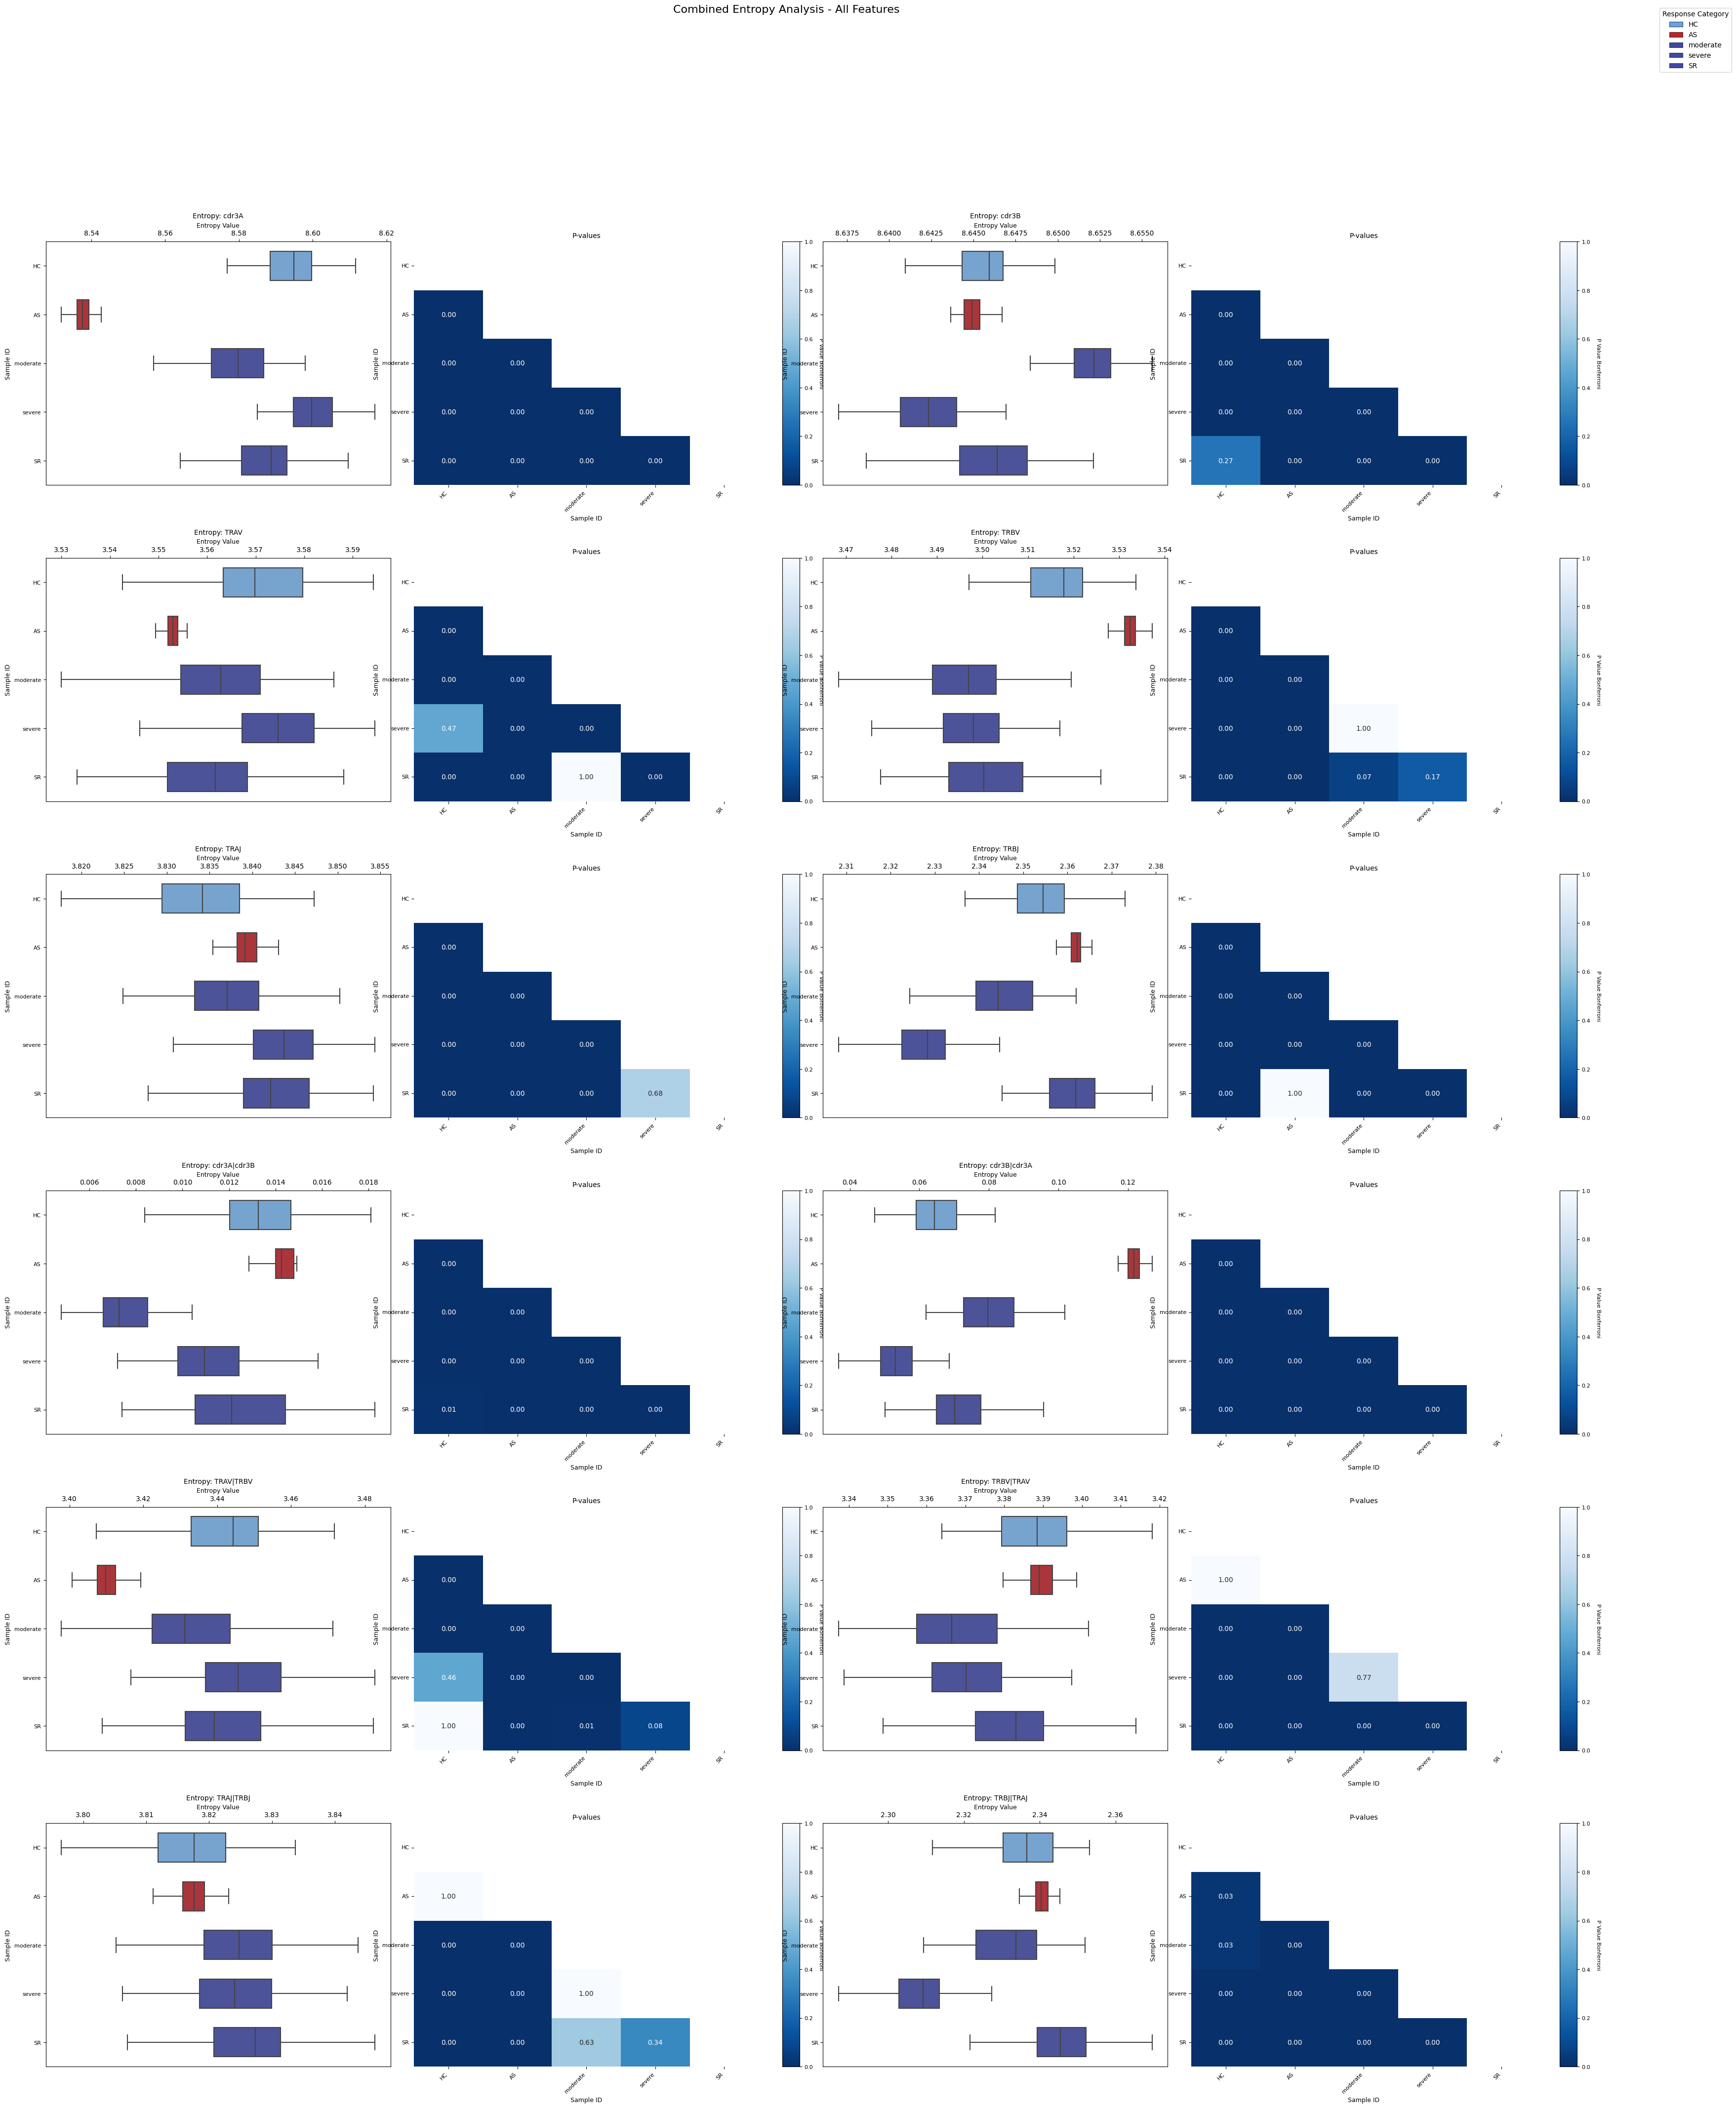

In [21]:
create_combined_entropy_plot("/mnt/d/TCRMI/results/covid/cohort/entropy.pickle", 
                  "/mnt/d/TCRMI/results/covid/cohort.pickle",
                  save_dir="/mnt/d/TCRMI/figures/covid/cohort",
                  select_features=['cdr3A','cdr3B','TRAV','TRBV',
                                   'cdr3A|cdr3B','cdr3B|cdr3A',
                                   'TRAV|TRBV','TRBV|TRAV'])